Please note contents of this notebook will produce different values to the lecture notes due to differing seed values and python versions.

## Load Libraries & Data

In [1]:
import platform
print(platform.python_version())

3.14.4


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from string import ascii_letters
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [3]:
dataset = read_csv("classification_example_creditcard.csv")

## Data Exploration

In [4]:
dataset.shape

(284807, 31)

In [5]:
dataset.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Look at aggregate statistics on the data

In [6]:
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
class_names = {0:'Not Fraud', 1:'Fraud'}
print(dataset.Class.value_counts().rename(index=class_names))

Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64


Classes are unbalanced - we will have to deal with this!

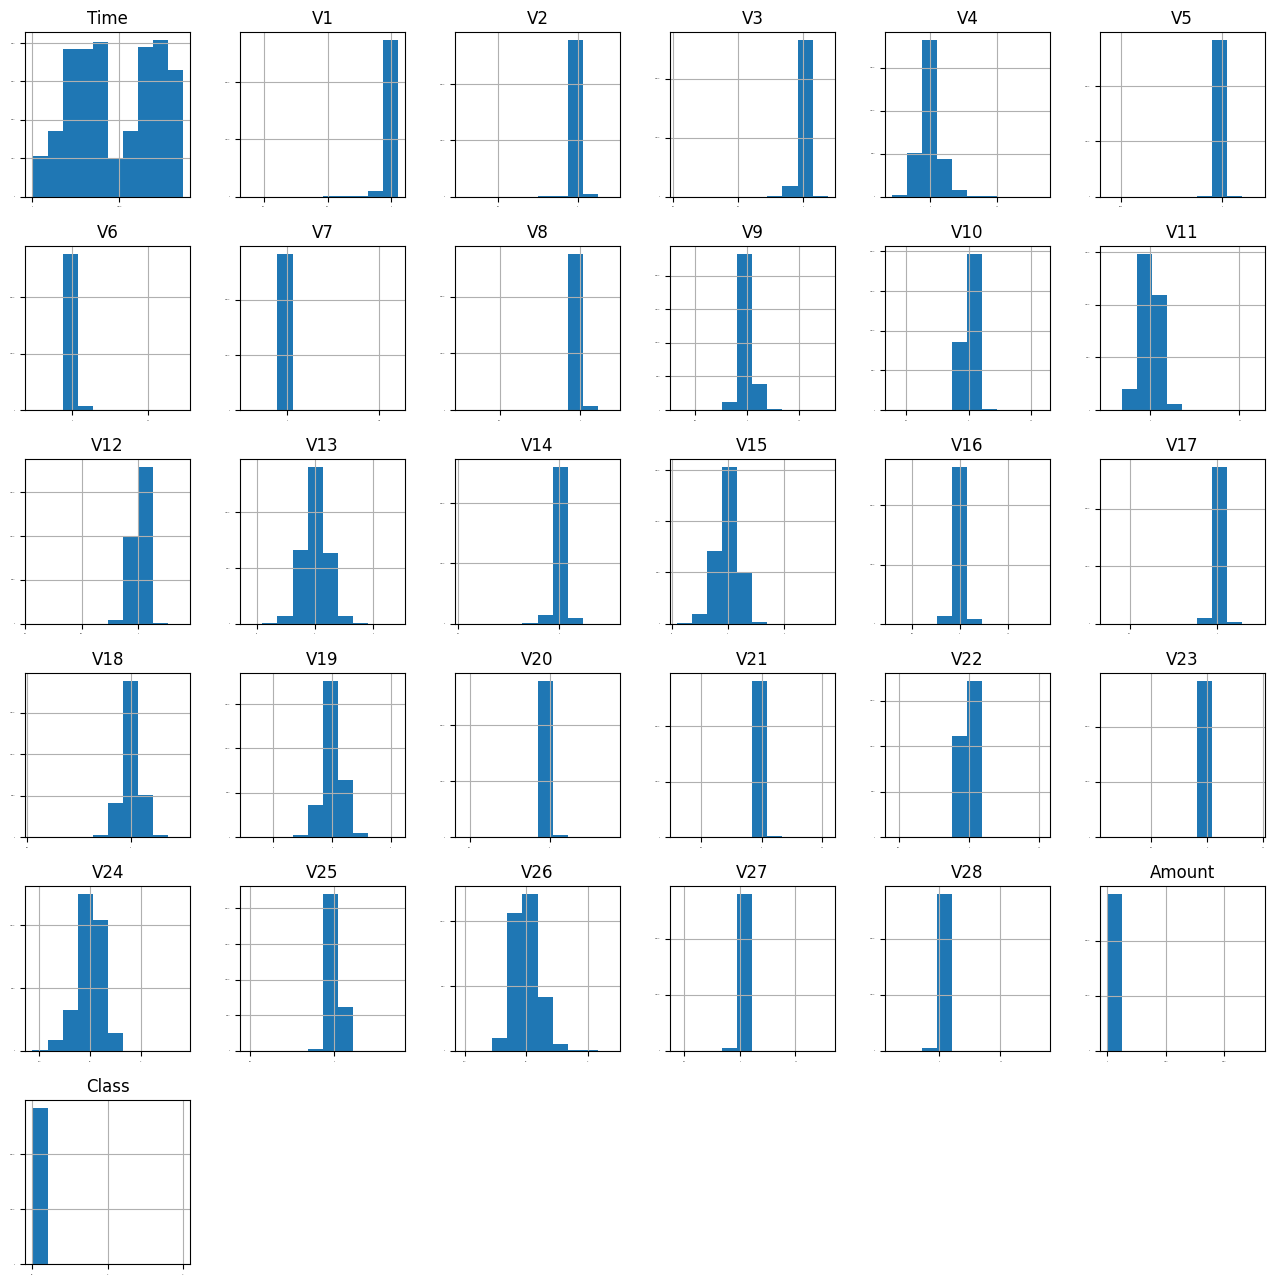

In [8]:
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(16,16))
pyplot.show()

We see skewness, but given the fact that we don't know what the variables are we can't do much

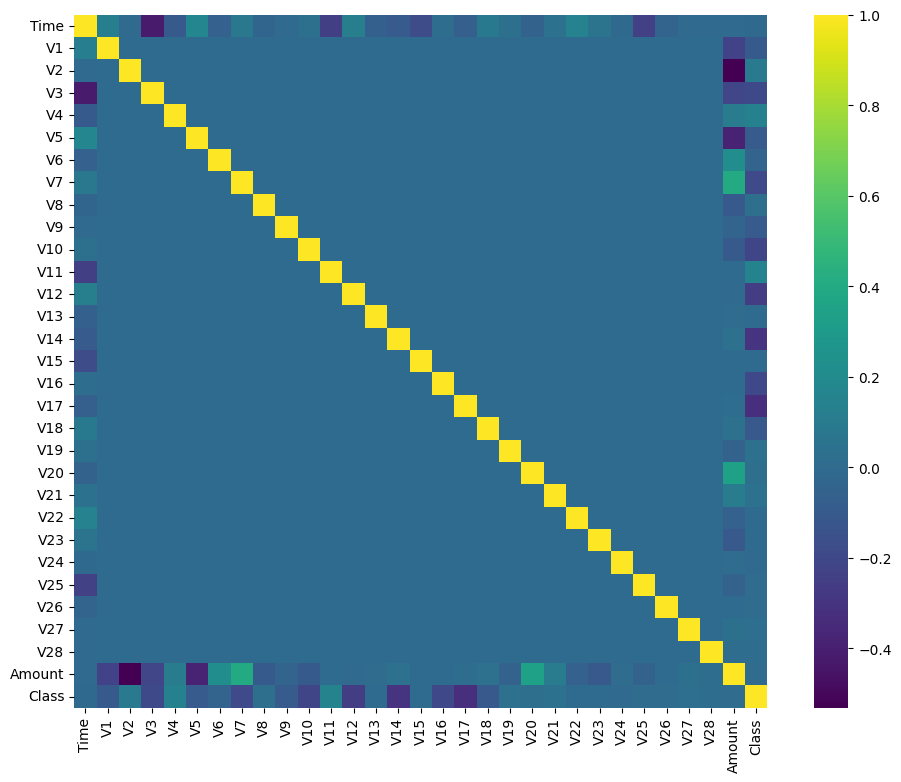

In [9]:
correlation_matrix = dataset.corr()
plt.figure(figsize=(12,9))
sns.heatmap(correlation_matrix, vmax=1, square=True, cmap='viridis')
plt.show()

<Axes: >

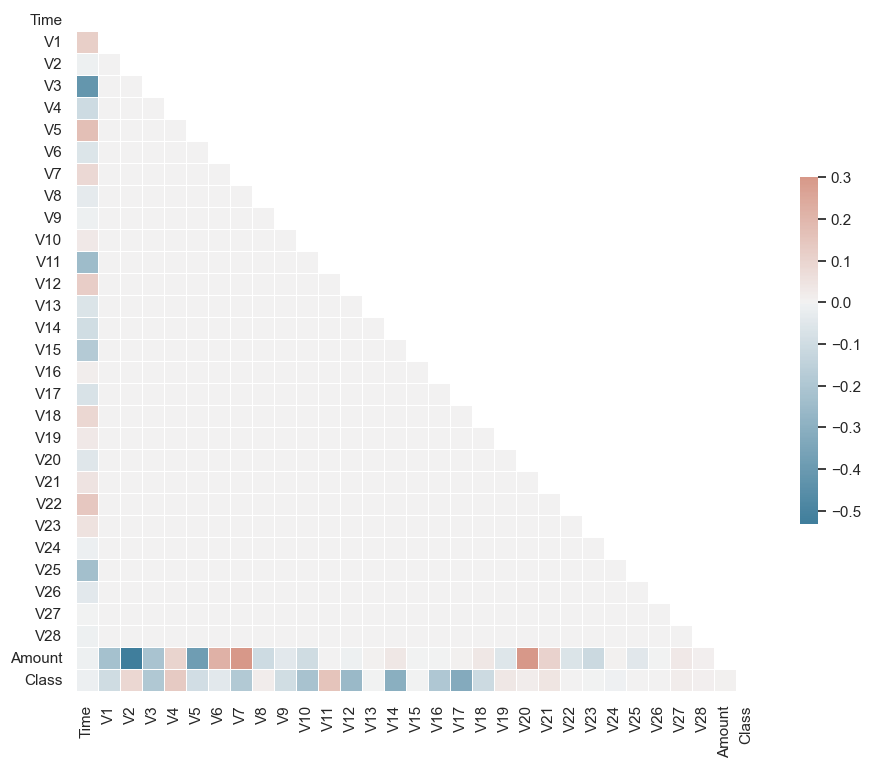

In [10]:
sns.set_theme(style="white")
corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Although the PCA components are not correlated, we do see that there is correlation between them and the other variables of interest

## Feature Selection

In [11]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

bestfeatures = SelectKBest( k=10)
bestfeatures
Y= dataset["Class"]
X = dataset.loc[:, dataset.columns != 'Class']
fit = bestfeatures.fit(X,Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']
print(featureScores.nlargest(10,'Score'))

   Specs         Score
17   V17  33979.168593
14   V14  28695.547788
12   V12  20749.822361
10   V10  14057.979985
16   V16  11443.349428
3     V3  11014.508305
7     V7  10349.605408
11   V11   6999.355047
4     V4   5163.832114
18   V18   3584.380605


We see that although there are relevant features, we don't know what they mean

## Evaluate Some Models Quickly

In [23]:
Y= dataset["Class"]
X = dataset.loc[:, dataset.columns != 'Class']
validation_size = 0.2
seed = 32
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed, shuffle=True)
scoring = 'accuracy'

In [24]:
for i in [X_train, X_validation, Y_train, Y_validation]:
    print(i.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [25]:
num_folds = 10
models = []
models.append(('LR', LogisticRegression(random_state=seed, max_iter=5000)))
models.append(('CART', DecisionTreeClassifier(random_state=seed, max_depth=10, min_samples_split=20)))

Remember, the dataset is huge, so we should only use some simpler models. Here we use Logistic Regression and Classification and Regression Trees

In [26]:
from sklearn.preprocessing import StandardScaler

# initialize the scaler
scaler = StandardScaler()

# scale the features (X)
# important: scale X_train before passing it to cross_val_score
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 1.20764306, -0.16270216,  0.99081019, ...,  0.3734089 ,
         0.79246085, -0.26972767],
       [-1.9442226 ,  0.59509705,  0.13958839, ..., -0.02937527,
         0.09352522, -0.29617486],
       [ 1.23522341,  0.73062371, -0.83542352, ..., -0.23106041,
        -0.06724883,  0.8576378 ],
       ...,
       [-0.81963906, -1.70549835, -0.85311055, ...,  1.07398306,
         2.17450254,  0.43888409],
       [-0.32315063,  0.74024178, -0.2734081 , ...,  0.02695066,
         0.04696881, -0.28827607],
       [-1.59908925, -0.3567994 ,  0.26021336, ..., -0.15653064,
        -0.46684   , -0.30065477]], shape=(227845, 30))

In [27]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(
        model, 
        X_train_scaled, 
        Y_train, 
        cv=kfold, 
        scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.999184 (0.000208)
CART: 0.999386 (0.000213)


In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline

results = []
names = []

for name, model in models:
    # build per-fold pipeline (prevents leakage & helps convergence)
    pipeline = make_pipeline(StandardScaler(), model)

    # better for imbalanced classes than plain KFold
    cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
    
    cv_results = cross_val_score(
        pipeline, 
        X_train,            # raw X is fine now because scaling is inside pipeline
        Y_train, 
        cv=cv, 
        scoring=scoring,
        n_jobs=-1)          # use all CPU cores
    
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)


LR: 0.999188 (0.000123)
CART: 0.999394 (0.000149)


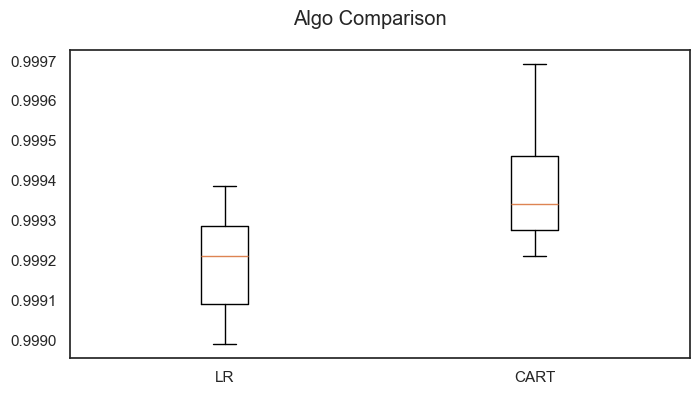

In [29]:
fig = pyplot.figure()
fig.suptitle('Algo Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(8,4)
pyplot.show()

We see the accuracy is quite high for both the cases with the algorithms with cross validation and 10 folds. Lets see how the performance is on unseen data with CART first and then Logistic Regression.

In [30]:
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [31]:
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print('--------------------------------------------------------')
print(confusion_matrix(Y_validation, predictions))
print('--------------------------------------------------------')
print(classification_report(Y_validation, predictions))

0.9989642217618764
--------------------------------------------------------
[[56822    28]
 [   31    81]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56850
           1       0.74      0.72      0.73       112

    accuracy                           1.00     56962
   macro avg       0.87      0.86      0.87     56962
weighted avg       1.00      1.00      1.00     56962



We see that the model has a high accuracy on the validation/test set. But is this the most important measure? Lets look at the confusion matrix.

<Axes: xlabel='Predicted', ylabel='Actual'>

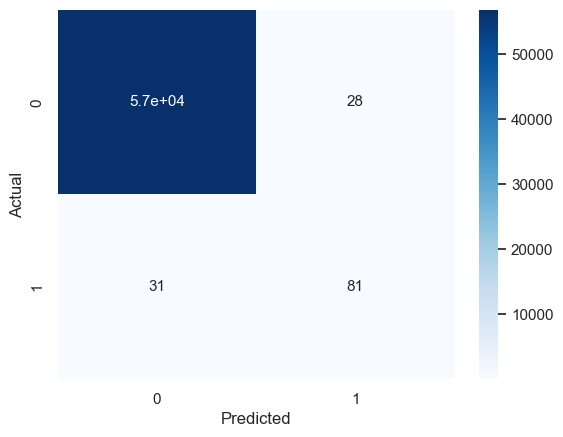

In [32]:
df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions), 
    columns=np.unique(Y_validation), 
    index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

We see that although its good at predicting frauds, it sill misses 22 cases. Lets see the performance with Logistic Regression.

0.9991222218320986
--------------------------------------------------------
[[56843     7]
 [   43    69]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56850
           1       0.91      0.62      0.73       112

    accuracy                           1.00     56962
   macro avg       0.95      0.81      0.87     56962
weighted avg       1.00      1.00      1.00     56962



<Axes: xlabel='Predicted', ylabel='Actual'>

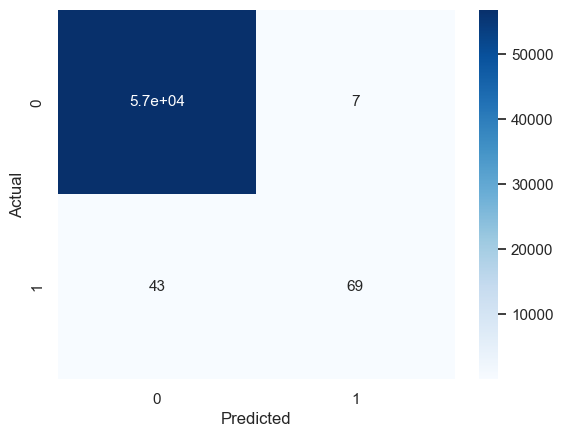

In [22]:
model = LogisticRegression(random_state=seed, max_iter=5000)
model.fit(X_train, Y_train)
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print('--------------------------------------------------------')
print(confusion_matrix(Y_validation, predictions))
print('--------------------------------------------------------')
print(classification_report(Y_validation, predictions))
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

The Logistic Regression model is not too much worse than the CART model. It has 38 false negatives. Lets try and improve our models with undersampling.

## Undersampling

In [33]:
Y_train.value_counts()

Class
0    227465
1       380
Name: count, dtype: int64

We see that our validation/test set contains 112 out of the 492 fraud instances. We have 380 fraud instances in the training set. Lets undersample with these. Here we look to take randomly 380 non fraud cases to match with the 380 fraud case and train a model with this smaller set.

In [34]:
df = pd.concat([X_train, Y_train], axis=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0].sample(frac=1, random_state=seed)[:380]
df_new = pd.concat([fraud_df, non_fraud_df])
# Shuffle the dataset
df_new = df_new.sample(frac=1, random_state=seed).reset_index(drop=True)
Y_train_new = df_new["Class"]
X_train_new = df_new.loc[:, dataset.columns != 'Class']

In [35]:
for i in [X_train_new, Y_train_new]:
    print(i.shape)

(760, 30)
(760,)


Distribution of the Classes in the subsample dataset
Class
1    0.5
0    0.5
Name: count, dtype: float64


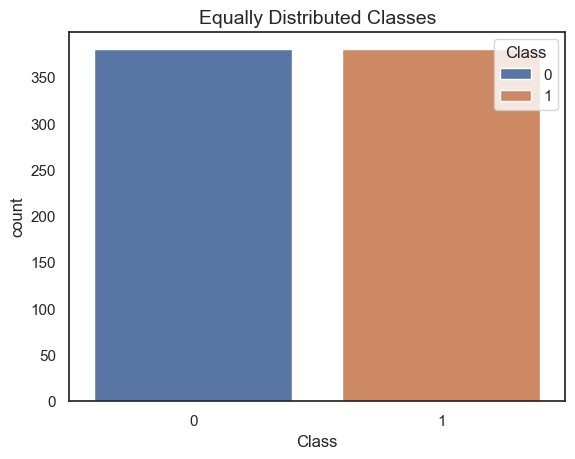

In [36]:
print('Distribution of the Classes in the subsample dataset')
print(df_new['Class'].value_counts()/len(df_new))
sns.countplot(x='Class', data=df_new, hue='Class')
pyplot.title('Equally Distributed Classes', fontsize=14)
pyplot.show()

We now have as many fraudulent and non-fraudulent cases, 405 instances of each.

## Try models with undersampled data

In [37]:
scoring='accuracy'

In [38]:
models = []
models.append(('LR', LogisticRegression(random_state=seed, max_iter=5000)))
models.append(('CART', DecisionTreeClassifier(random_state=seed, max_depth=10, min_samples_split=20)))

In [39]:
from sklearn.preprocessing import StandardScaler

# initialize the scaler
scaler = StandardScaler()

# scale the features (X)
# important: scale X_train_new before passing it to cross_val_score
X_train_new_scaled = scaler.fit_transform(X_train_new)
X_train_new_scaled

array([[-0.99615646, -1.98026664,  1.37022758, ..., -1.33552414,
        -1.01570254, -0.43270782],
       [-1.6225535 ,  0.60564254,  0.62702199, ...,  0.53255889,
         0.13844335, -0.43175655],
       [-1.44786825,  0.40963542, -0.44624079, ..., -0.28960213,
        -0.35678421, -0.41590198],
       ...,
       [-0.24550595,  0.63458894, -0.19980873, ...,  0.03823148,
         0.07449909, -0.43175655],
       [ 1.1783847 ,  0.76351472, -0.57296702, ..., -0.08817978,
        -0.15141311, -0.13281863],
       [ 1.32904678,  0.76173593, -0.88516147, ..., -0.01341948,
        -0.14253355,  0.04705146]], shape=(760, 30))

In [40]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train_new_scaled, Y_train_new, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.942105 (0.023684)
CART: 0.901316 (0.033417)


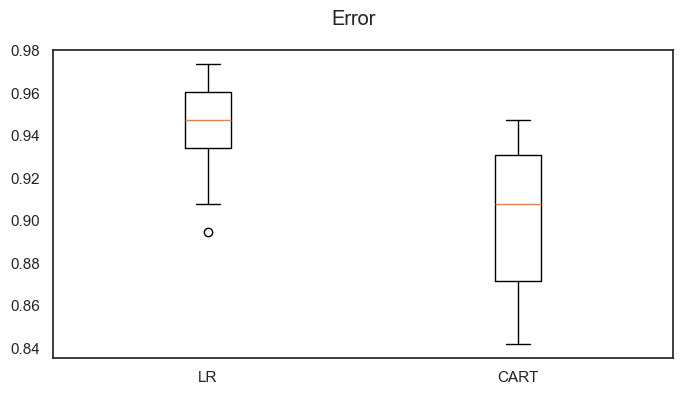

In [41]:
fig = pyplot.figure()
fig.suptitle('Error')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(8,4)
pyplot.show()

The Logistic Regression model appears to be more accurate than the CART model with this dataset. Lets run both models now on the full validation/test set.

In [42]:
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train_new, Y_train_new)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [43]:
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8932095080931147
[[50783  6067]
 [   16    96]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     56850
           1       0.02      0.86      0.03       112

    accuracy                           0.89     56962
   macro avg       0.51      0.88      0.49     56962
weighted avg       1.00      0.89      0.94     56962



<Axes: xlabel='Predicted', ylabel='Actual'>

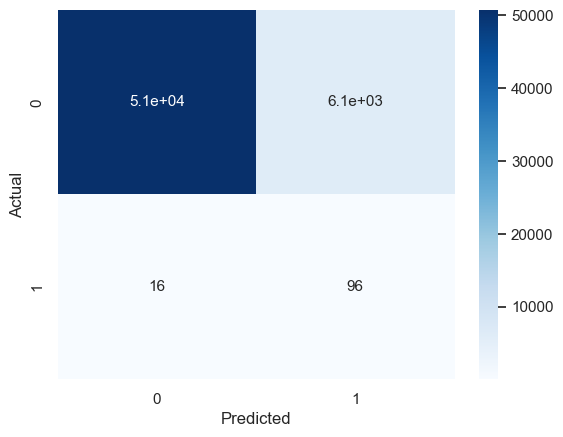

In [44]:
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

0.9667848741266107
[[54970  1880]
 [   12   100]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56850
           1       0.05      0.89      0.10       112

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.54     56962
weighted avg       1.00      0.97      0.98     56962



c:\Users\minim\MLcoursework\Classification Example\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: xlabel='Predicted', ylabel='Actual'>

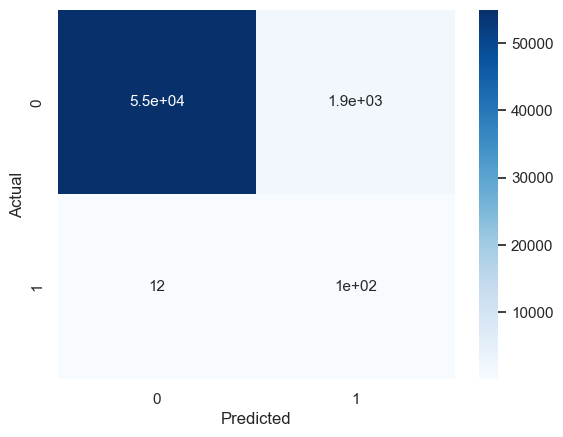

In [45]:
model = LogisticRegression(random_state=seed, max_iter=5000)
model.fit(X_train_new, Y_train_new)
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 11})

We see that the number of false negatives decreases in both cases with the models. The Logistic Regression model improves much more than the CART model. Note how as the number of false negatives decreases, we see a large increase in the number of false positives. To improve the model, we could take further measures to reduce false negatives whilst also trying to control the increase in false positives.

There are a number of further steps we could take:
- Try different methods to deal with unbalanced data
- Regularise our models
- Try more complex models
- Feature engineering

## References
Adapted from *Machine Learning & Data Science Blueprints for Finance*; Tatsat et al.